# Анализ запусков тестов

In [843]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import src.algorithm as algorithm
import time

def print_info(df: pd.DataFrame):
    return pd.DataFrame([
        [df['dummy_time'].mean(), df['fomin_time'].mean()],
        [df['dummy_time'].max(), df['fomin_time'].max()],
        [df['dummy_time'].min(), df['fomin_time'].min()],
        [np.sqrt(np.var(df['dummy_time'].to_numpy())), np.sqrt(np.var(df['fomin_time'][df['fomin_time'] > df['fomin_time'].min() * 2].to_numpy()))]
    ], columns=["Dummy", "Fomin"], index=["Mean", "Max", "Min", "MSE"]).style.format("{:.2f}")

def to_nx_graph(graph: dict[int, set]):
    for key in graph:
        graph[key] = list(graph[key])

    return nx.Graph(graph)

def from_nx_graph(graph: nx.Graph):
    graph = nx.to_dict_of_lists(graph)
    
    for key in graph:
        graph[key] = set(graph[key])

    return graph
    

def draw_graphs(df, limit: int):
    df = df.head(limit)
    Gs = [(to_nx_graph(g), cds) for g, cds in zip(df["graph"], df["fomin_cds"])]

    for G, cds in Gs:
        nx.draw(G, with_labels=True)
        plt.title(f"CDS: {cds}")
        plt.show()

def draw_hardest(test: str, limit: int = 10):
    df = pd.read_pickle(f"tests_data/{test}.pkl").sort_values(by="fomin_time", ascending=False)
    draw_graphs(df, limit)

def draw_easiest(test: str, limit: int = 10):
    df = pd.read_pickle(f"tests_data/{test}.pkl").sort_values(by="fomin_time", ascending=True)
    draw_graphs(df[df["dummy_cds"].str.len() > 1], limit)

## Хордальные графы

Для графов с 5 вершинами:

In [844]:
print_info(pd.read_pickle("tests_data/chordal5.pkl"))

,Dummy,Fomin
Mean,83.46,204.26
Max,113.62,820.04
Min,60.88,8.62
MSE,15.62,252.87


Для графов с 9 вершинами:

In [845]:
print_info(pd.read_pickle("tests_data/chordal9.pkl"))

,Dummy,Fomin
Mean,776.33,3700.20
Max,4008.62,26288.96
Min,305.25,4.17
MSE,220.01,2084.66


Посмотрим на графы, на которых достигалось минимальное и максимальное время (кроме графов, у которых все получалось слишком быстро из-за проверки, что одна вершина --- не CDS)

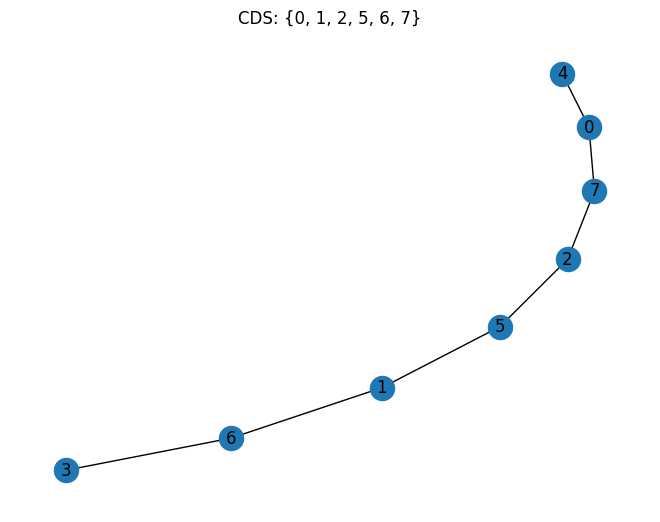

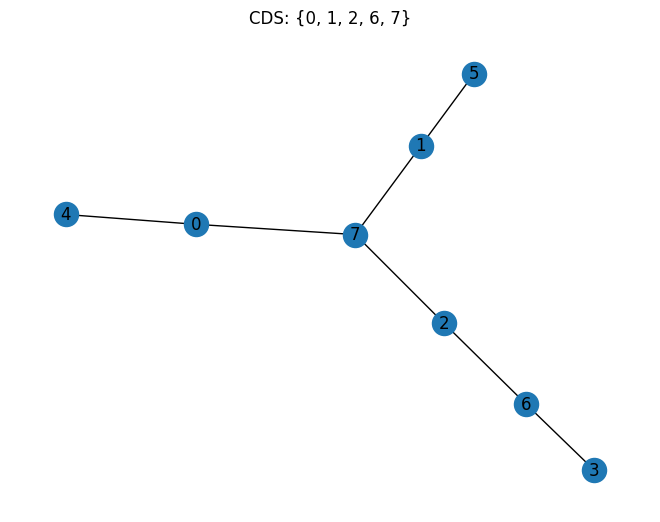

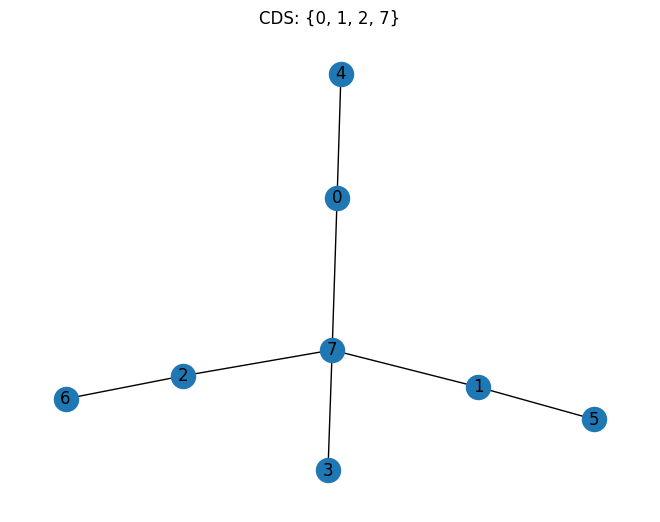

In [846]:
draw_easiest("chordal8", 3)

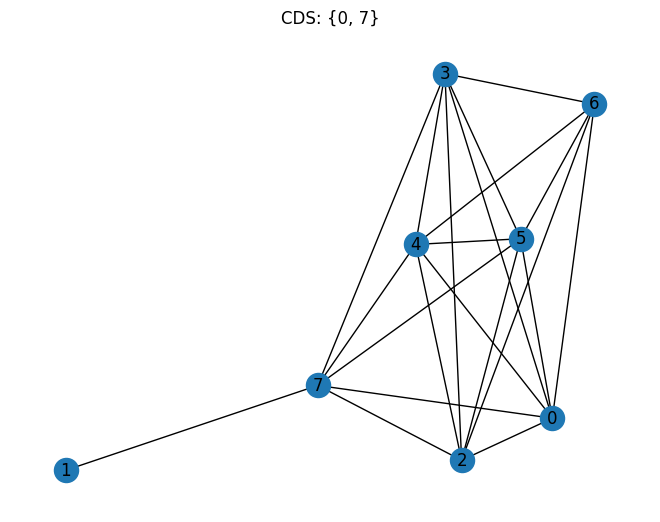

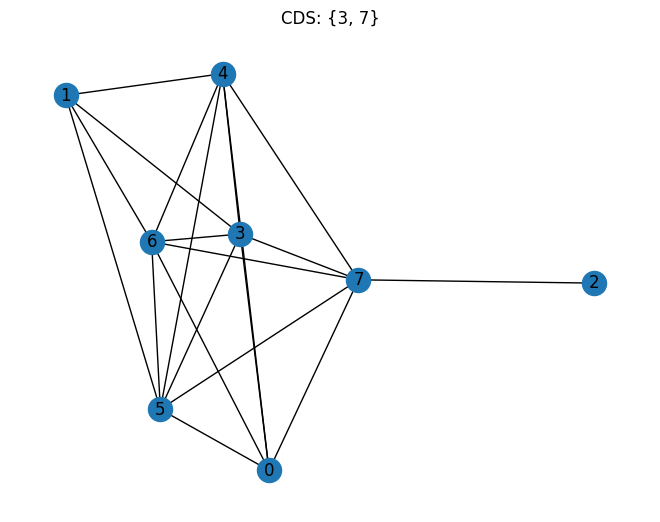

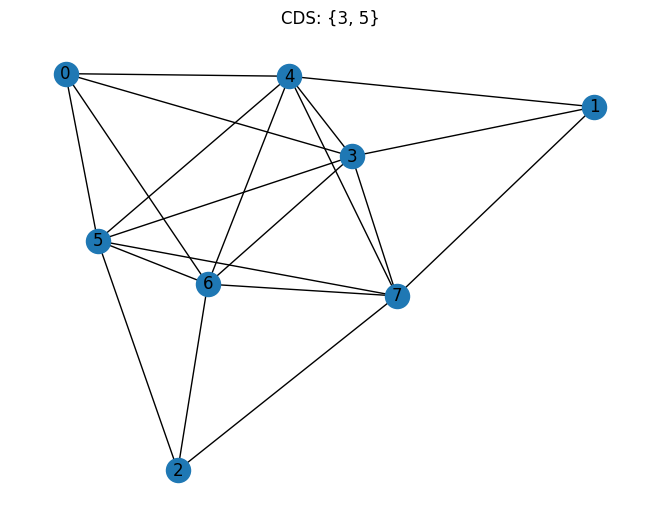

In [847]:
draw_hardest("chordal8", 3)

Видно, что, все графы имеют большое количество ребер, поэтому рекурсивный спуск занимает достаточно большое время.

## Эйлеровы графы

Для графов с 5 вершинами:

In [848]:
print_info(pd.read_pickle("tests_data/eul5c.pkl"))

,Dummy,Fomin
Mean,83.46,180.52
Max,121.75,695.00
Min,57.04,7.50
MSE,24.11,0.00


Для графов с 8 вершинами:

In [849]:
print_info(pd.read_pickle("tests_data/eul8c.pkl"))

,Dummy,Fomin
Mean,405.05,3278.03
Max,762.25,6521.33
Min,199.67,1582.29
MSE,98.07,759.58


Посмотрим на графы, на которых достигалось минимальное и максимальное время (кроме графов, у которых все получалось слишком быстро из-за проверки, что одна вершина --- не CDS)

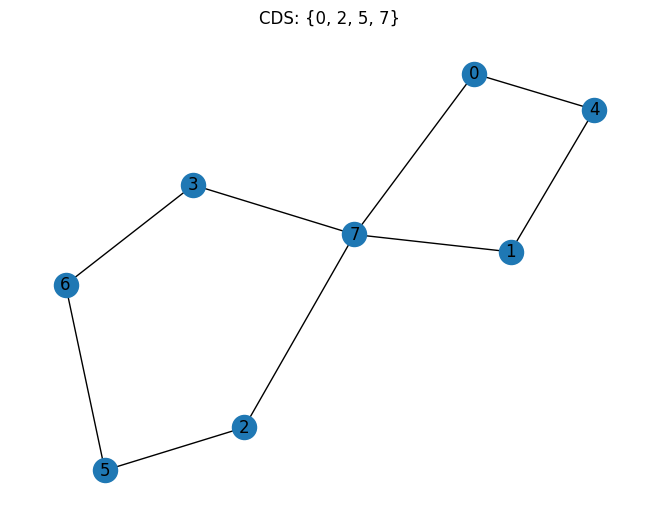

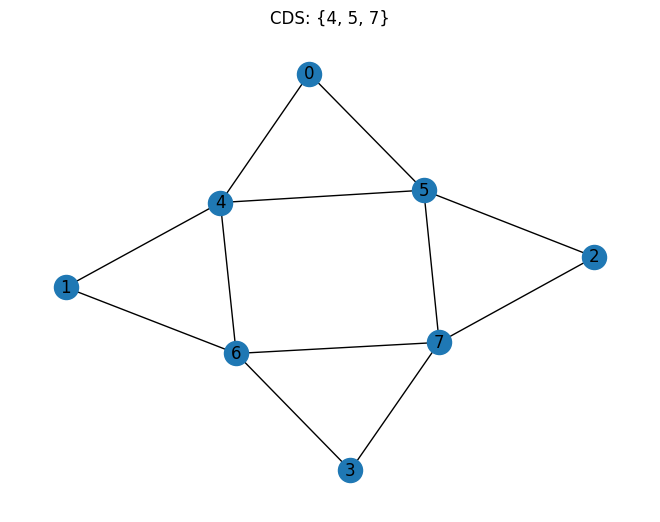

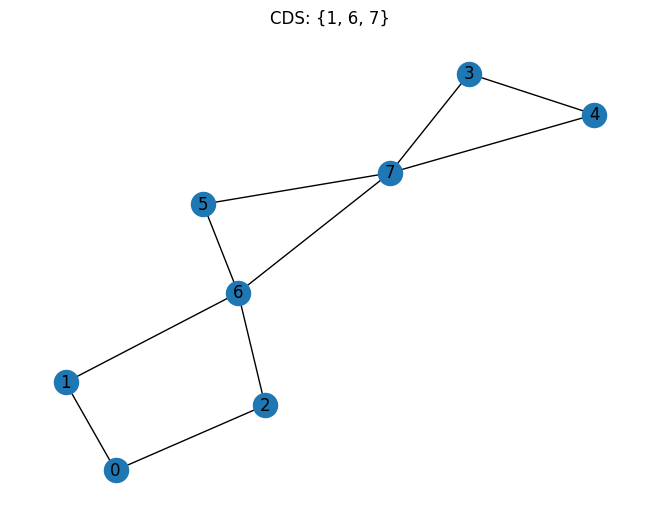

In [850]:
draw_easiest("eul8c", 3)

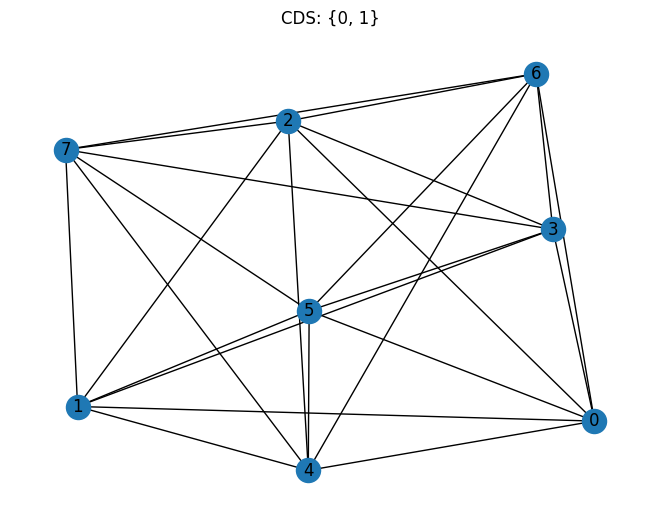

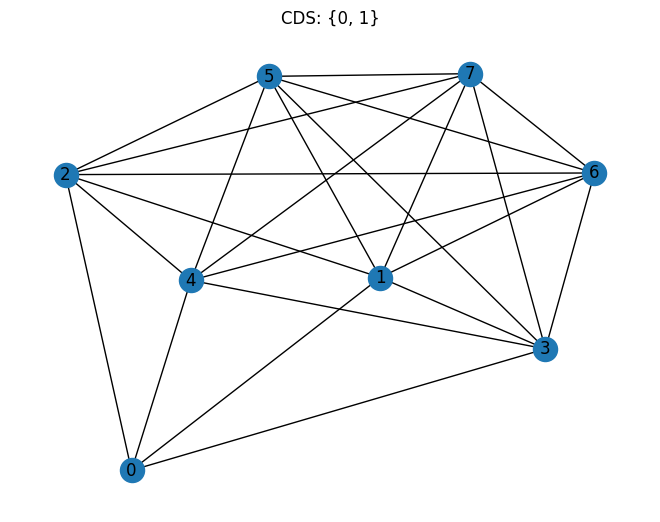

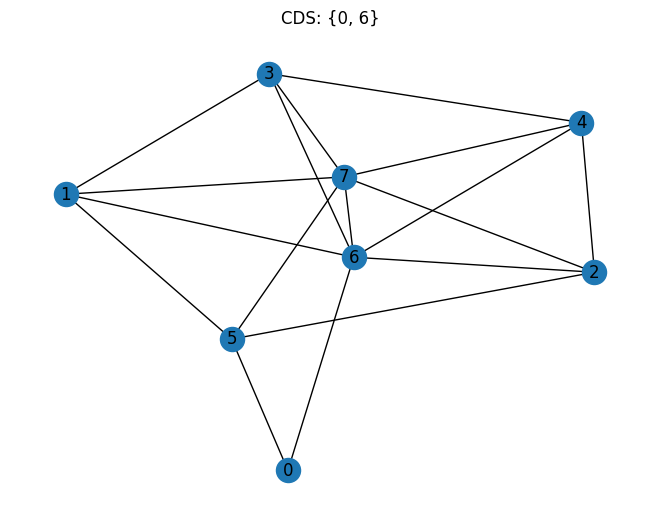

In [851]:
draw_hardest("eul8c", 3)

Опять же видим, что с увеличением количества ребер, алгоритму становится тяжелее.

## Совершенные графы

Для графов с 5 вершинами:

In [852]:
print_info(pd.read_pickle("tests_data/perfect5.pkl"))

,Dummy,Fomin
Mean,44.29,152.76
Max,90.21,481.25
Min,30.38,3.92
MSE,12.66,97.39


Для графов с 8 вершинами:

In [853]:
print_info(pd.read_pickle("tests_data/perfect8.pkl"))

,Dummy,Fomin
Mean,386.55,2558.89
Max,2354.17,14057.12
Min,155.83,4.62
MSE,101.58,1025.05


Посмотрим на графы, на которых достигалось минимальное и максимальное время (кроме графов, у которых все получалось слишком быстро из-за проверки, что одна вершина --- не CDS)

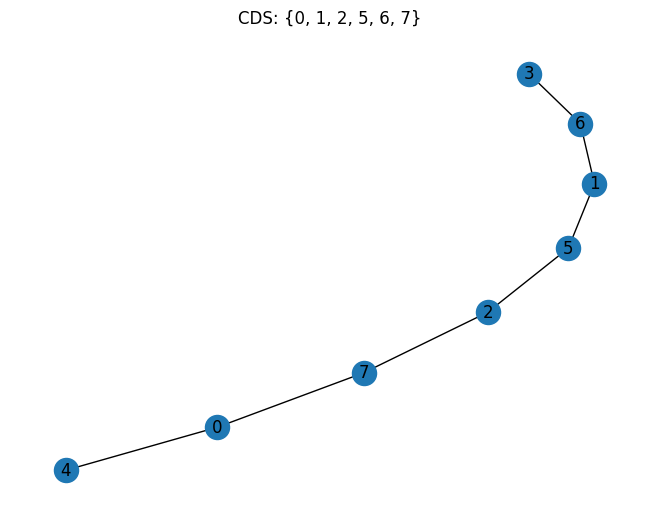

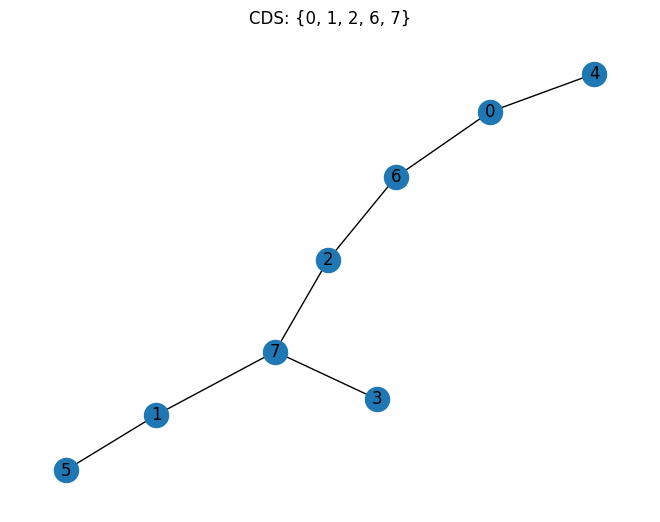

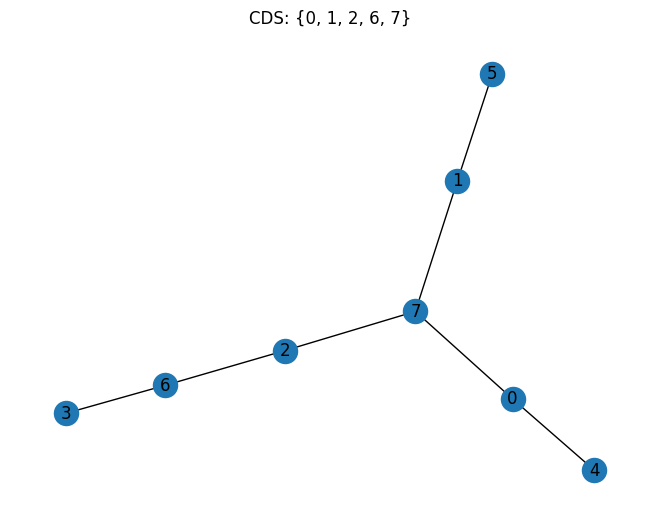

In [854]:
draw_easiest("perfect8", 3)

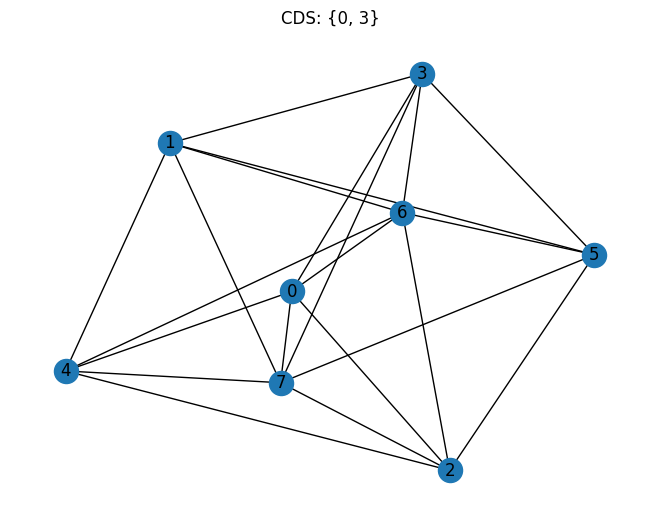

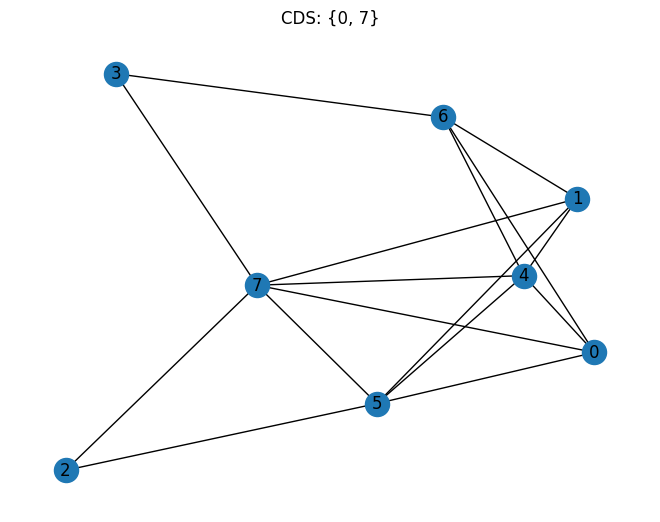

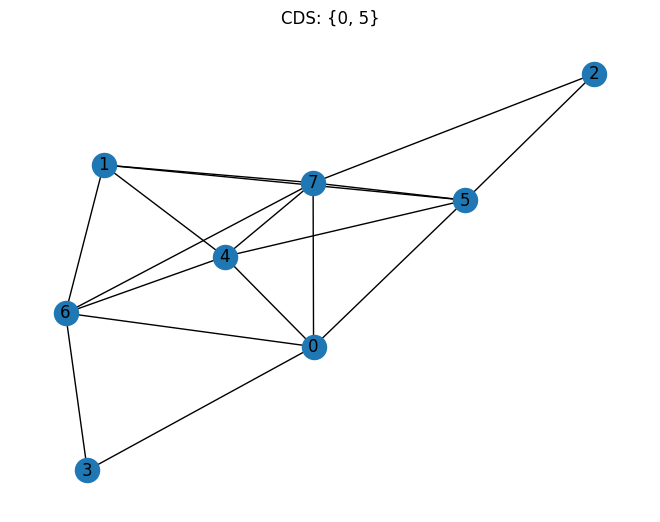

In [855]:
draw_hardest("perfect8", 3)

## Графы по количеству ребер

Для графов с 4 ребрами:

In [856]:
print_info(pd.read_pickle("tests_data/ge4c.pkl"))

,Dummy,Fomin
Mean,25.25,100.46
Max,41.96,192.54
Min,15.38,3.00
MSE,9.15,29.44


Для графов с 7 ребрами:

In [857]:
print_info(pd.read_pickle("tests_data/ge7c.pkl"))

,Dummy,Fomin
Mean,123.86,730.90
Max,229.67,1748.83
Min,54.67,4.17
MSE,39.64,193.31


Для графов с 11 ребрами:

In [858]:
print_info(pd.read_pickle("tests_data/ge11c.pkl"))

,Dummy,Fomin
Mean,956.44,2775.28
Max,8824.96,15206.75
Min,75.67,4.46
MSE,635.17,758.72


Посмотрим на графы, на которых достигалось минимальное и максимальное время (кроме графов, у которых все получалось слишком быстро из-за проверки, что одна вершина --- не CDS)

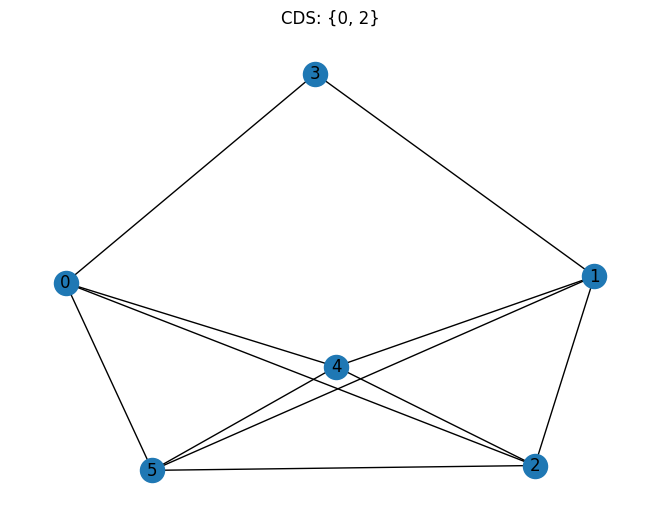

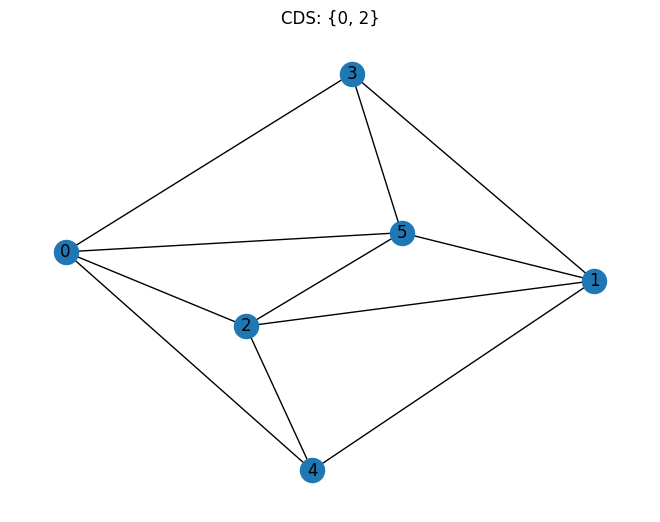

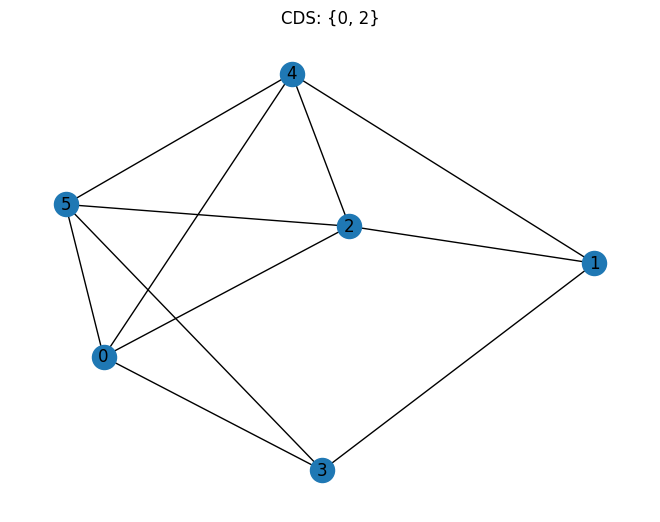

In [859]:
draw_easiest("ge11c", 3)

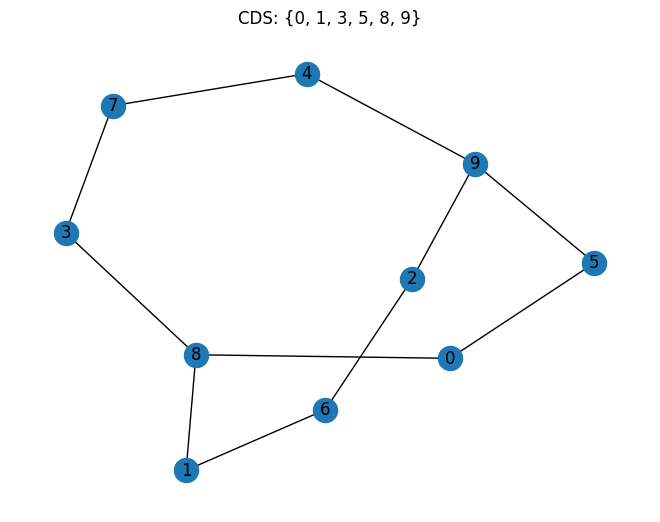

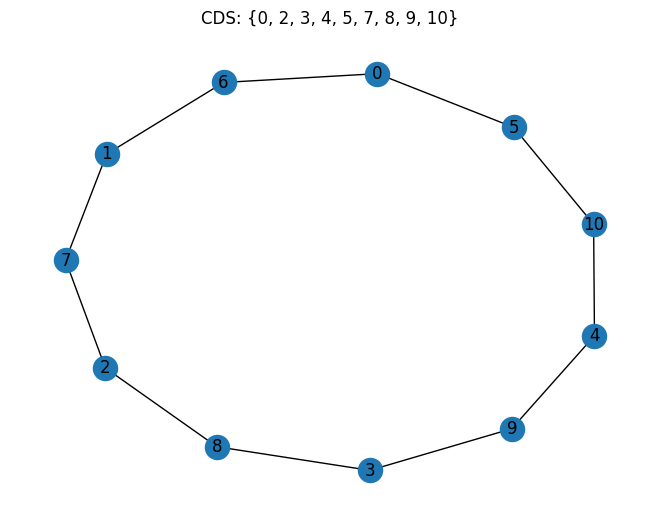

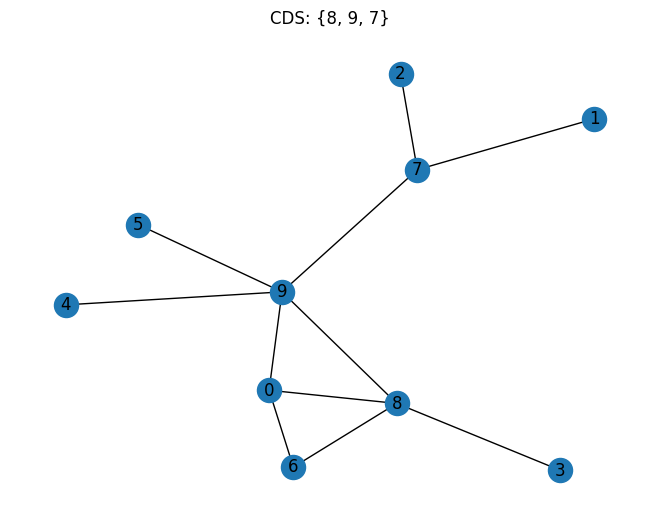

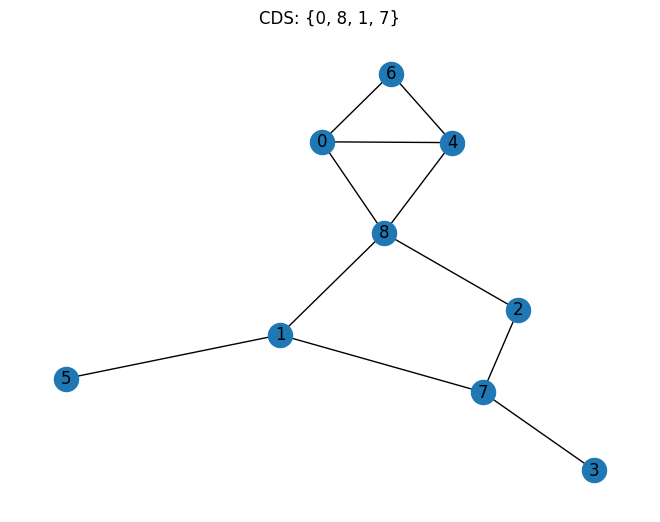

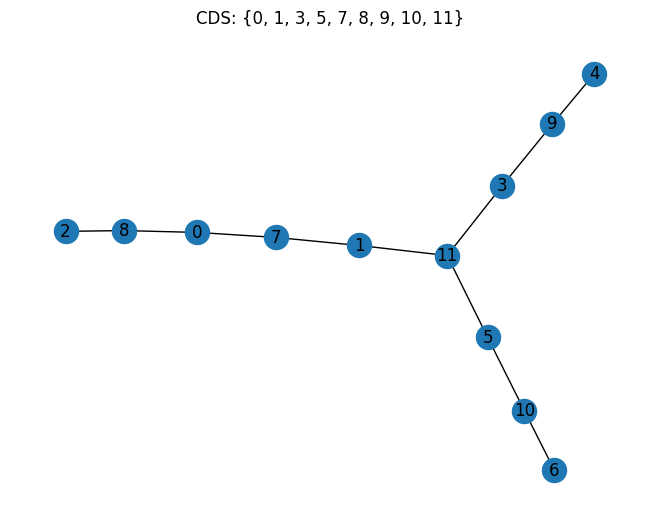

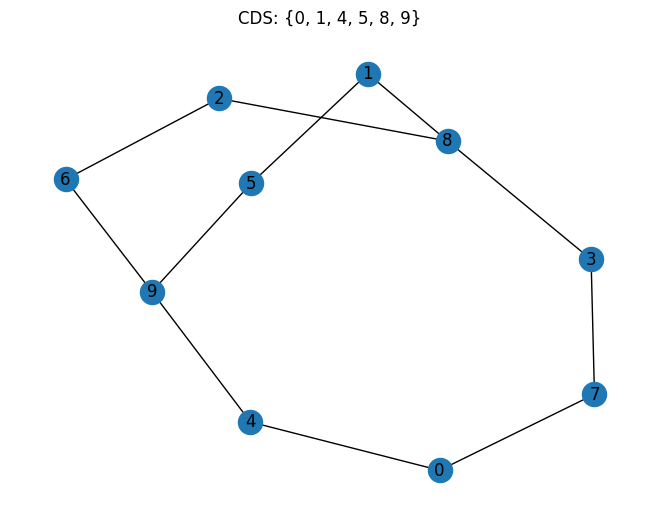

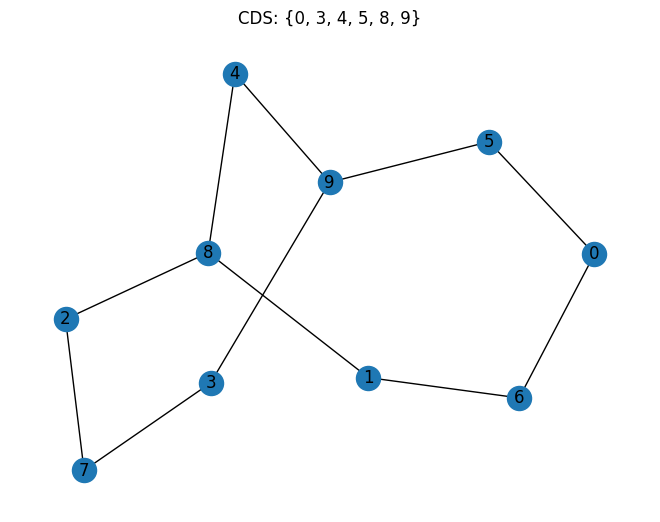

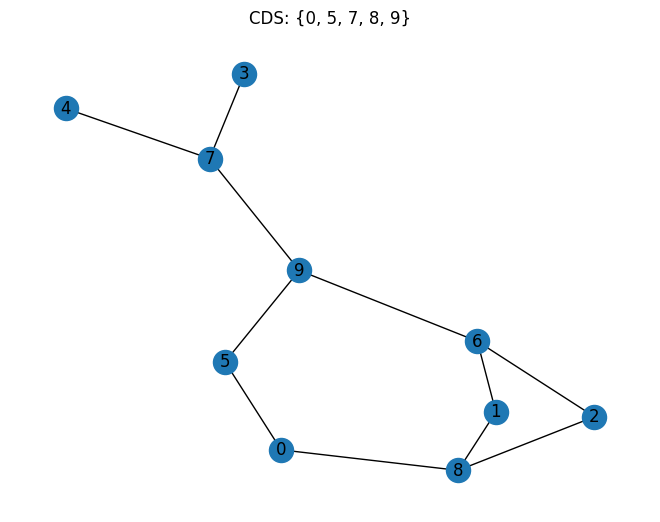

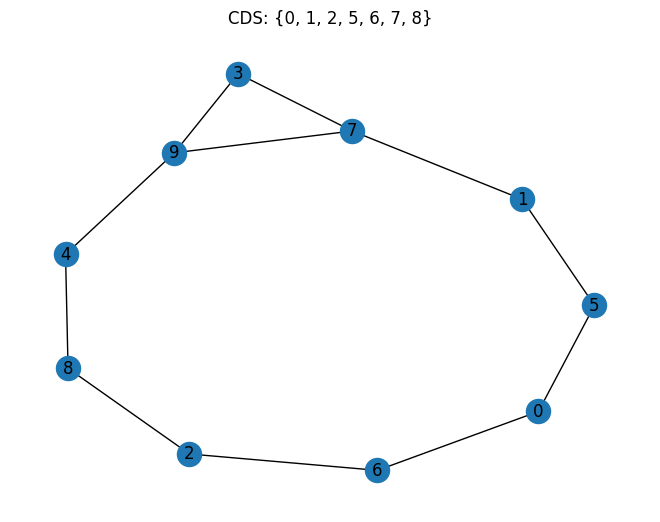

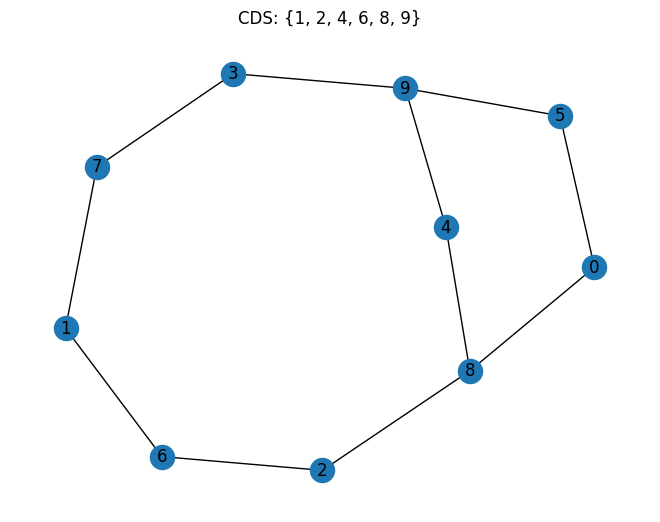

In [860]:
draw_hardest("ge11c")

## Большой $G(n, p)$ граф

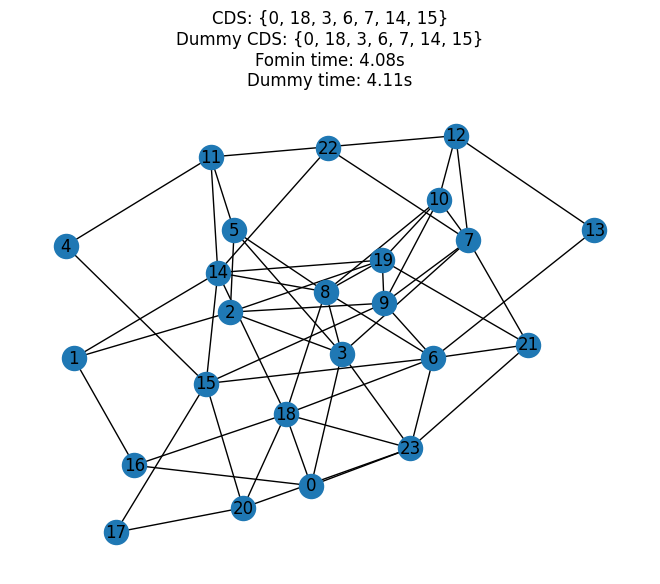

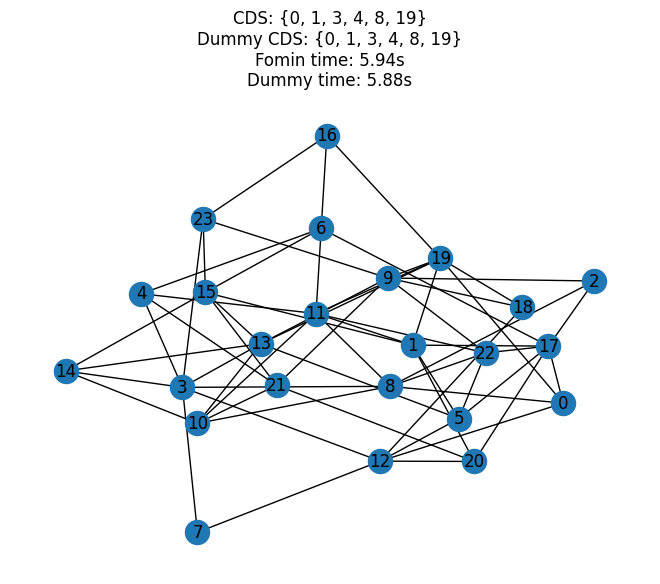

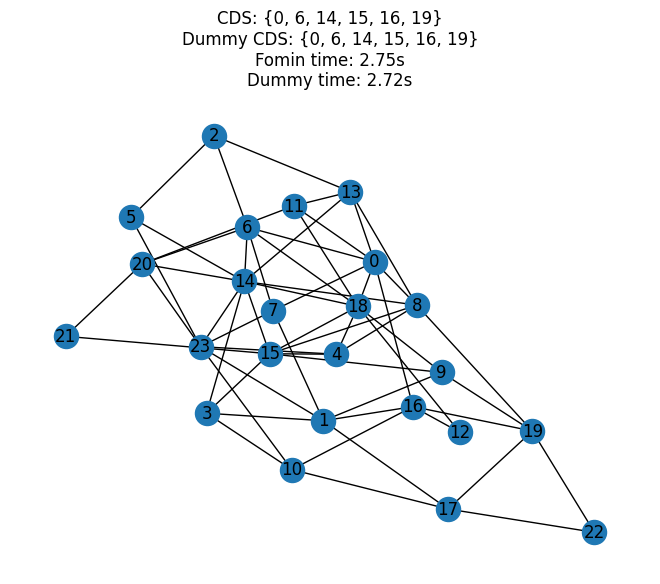

In [861]:
for i in range(3):
    graph = nx.gnp_random_graph(24, 0.2)

    cds_start = time.process_time_ns()
    cds = algorithm.find_cds(from_nx_graph(graph))
    cds_end = time.process_time_ns()

    dummy_start = time.process_time_ns()
    dummy_cds = algorithm.find_cds(from_nx_graph(graph))
    dummy_end = time.process_time_ns()

    nx.draw(graph, with_labels=True)
    plt.title(f"CDS: {cds}\nDummy CDS: {dummy_cds}\nFomin time: {(cds_end - cds_start) / 1000000000:.2f}s\nDummy time: {(dummy_end - dummy_start) / 1000000000:.2f}s")
    plt.show()

## Очень большой граф

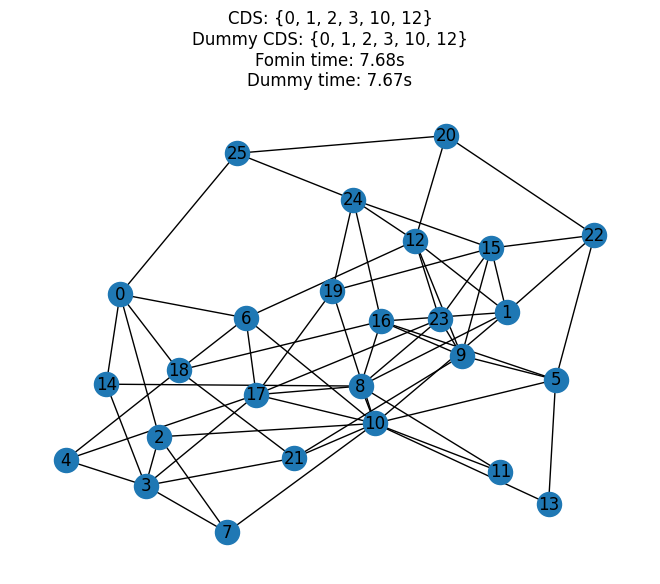

In [862]:
graph = nx.gnp_random_graph(26, 0.2)

cds_start = time.process_time_ns()
cds = algorithm.find_cds(from_nx_graph(graph))
cds_end = time.process_time_ns()

dummy_start = time.process_time_ns()
dummy_cds = algorithm.find_cds(from_nx_graph(graph))
dummy_end = time.process_time_ns()

nx.draw(graph, with_labels=True)
plt.title(f"CDS: {cds}\nDummy CDS: {dummy_cds}\nFomin time: {(cds_end - cds_start) / 1000000000:.2f}s\nDummy time: {(dummy_end - dummy_start) / 1000000000:.2f}s")
plt.show()